In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load the data
df = pd.read_csv("../data/raw_data/tanzania.csv") # Ensure you put your CSV in the data/ folder!

# 1. Immediate Clean: Replace NASA's -999 sentinel with NaN [cite: 114]
df.replace(-999, np.nan, inplace=True)

# 2. Date Conversion: Turn YEAR and DOY into a real date [cite: 111]
df['Date'] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df['Month'] = df['Date'].dt.month # Needed for seasonal analysis [cite: 112]

# 3. Add Country Column [cite: 110]
df['Country'] = 'Tanzania'

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month,Country
0,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61,2015-01-01,1,Ethiopia
1,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31,2015-01-02,1,Ethiopia
2,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30,2015-01-03,1,Ethiopia
3,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52,2015-01-04,1,Ethiopia
4,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16,2015-01-05,1,Ethiopia


In [2]:
###Data cleaning (sentinels and duplicates
            
# 1. Replace NASA's -999 sentinel with NaN [cite: 114, 398]
df.replace(-999, np.nan, inplace=True)

# 2. Handle duplicates [cite: 116]
duplicate_count = df.duplicated().sum()
print(f"Duplicates found: {duplicate_count}")
df.drop_duplicates(inplace=True)

# 3. Missing Value Report [cite: 118]
missing_pct = (df.isna().sum() / len(df)) * 100
print("\nMissing Values Percentage:")
print(missing_pct[missing_pct > 0])

Duplicates found: 0

Missing Values Percentage:
Series([], dtype: float64)


In [3]:
###statistical profiling

# Summary statistics for numeric columns [cite: 117]
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,26.802422,29.163493,25.03813,4.125363,3.740256,77.128038,4.105370,5.189248,100.801130,16.923683,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,22.680000,25.410000,20.03000,0.940000,0.000000,60.060000,1.120000,1.550000,100.150000,11.380000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.670000,28.090000,23.71000,3.330000,0.110000,73.167500,3.410000,4.377500,100.570000,15.340000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,26.990000,29.080000,25.37500,4.220000,0.640000,76.585000,4.190000,5.250000,100.760000,17.220000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,27.900000,30.170000,26.31000,4.940000,3.790000,81.100000,4.830000,5.980000,101.040000,18.420000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,29.970000,33.930000,28.01000,7.590000,122.650000,91.100000,8.400000,11.740000,101.510000,21.510000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.325388,1.371155,1.53544,1.102831,8.003947,5.070501,1.059803,1.215018,0.284461,1.881741,NaN,3.477046


In [3]:
### Outlier detection( z-scores)

# Flag rows where |Z| > 3 for key climate variables [cite: 121]
cols_to_check = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M']
outlier_report = {}

for col in cols_to_check:
    z_scores = np.abs(stats.zscore(df[col], nan_policy='omit'))
    outlier_report[col] = (z_scores > 3).sum()

print("Outlier counts (|Z| > 3):")
print(outlier_report)

# Handling strategy: We retain outliers as they often represent 
# actual extreme weather events critical for COP32[cite: 123].

Outlier counts (|Z| > 3):
{'T2M': np.int64(1), 'T2M_MAX': np.int64(2), 'T2M_MIN': np.int64(4), 'PRECTOTCORR': np.int64(81), 'RH2M': np.int64(2), 'WS2M': np.int64(8)}


<BarContainer object of 135 artists>

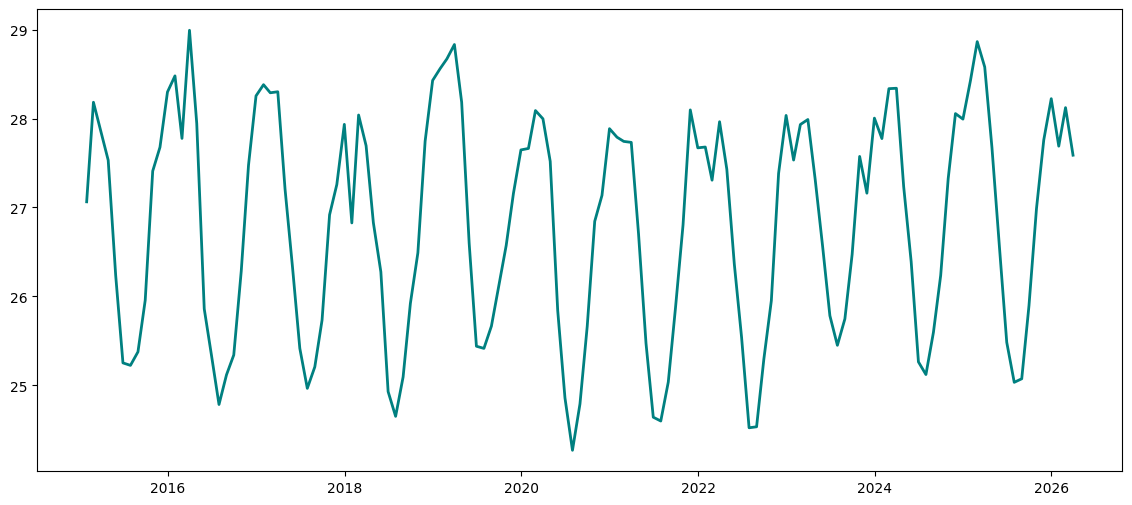

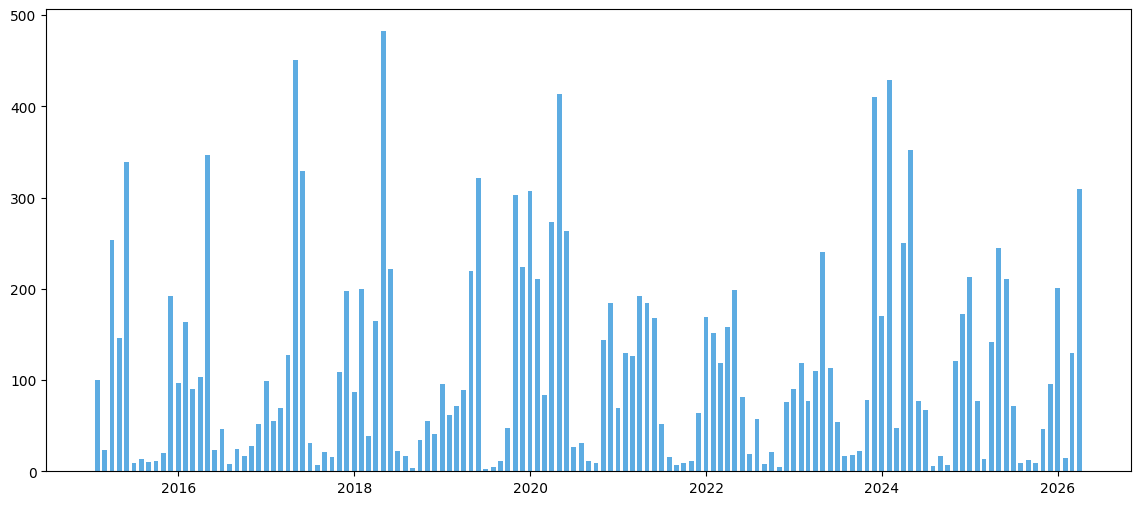

In [17]:
### Time series analysis
# 1. Plot monthly average Temperature (T2M)
plt.figure(figsize=(14, 6))

# Change 'M' to 'ME' (Month End)
monthly_temp = df.set_index('Date')['T2M'].resample('ME').mean() 

plt.plot(monthly_temp.index, monthly_temp.values, color='teal', linewidth=2)

# ... (the rest of your plotting code)

# 2. Plot monthly total Precipitation (PRECTOTCORR)
plt.figure(figsize=(14, 6))
# Change 'M' to 'ME' here as well
monthly_precip = df.set_index('Date')['PRECTOTCORR'].resample('ME').sum()
plt.bar(monthly_precip.index, monthly_precip.values, width=20, color='#3498db', alpha=0.8)
# ... (the rest of your plotting code)

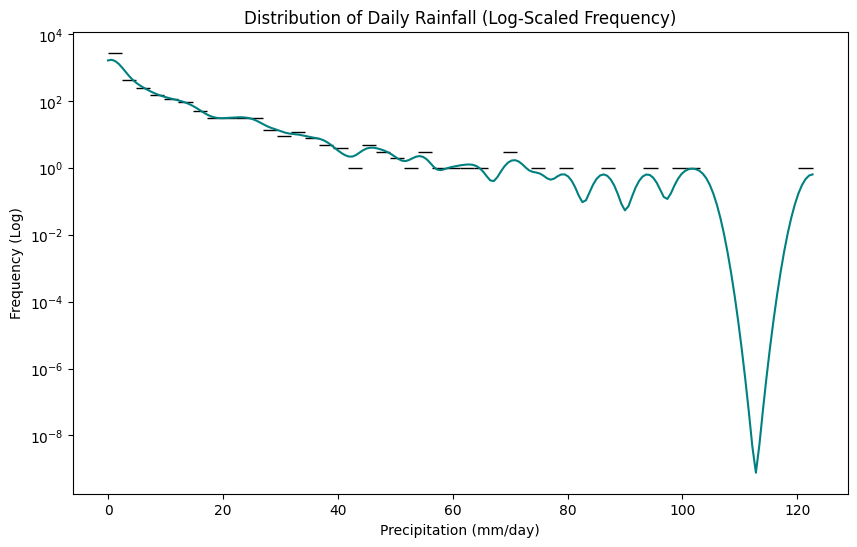

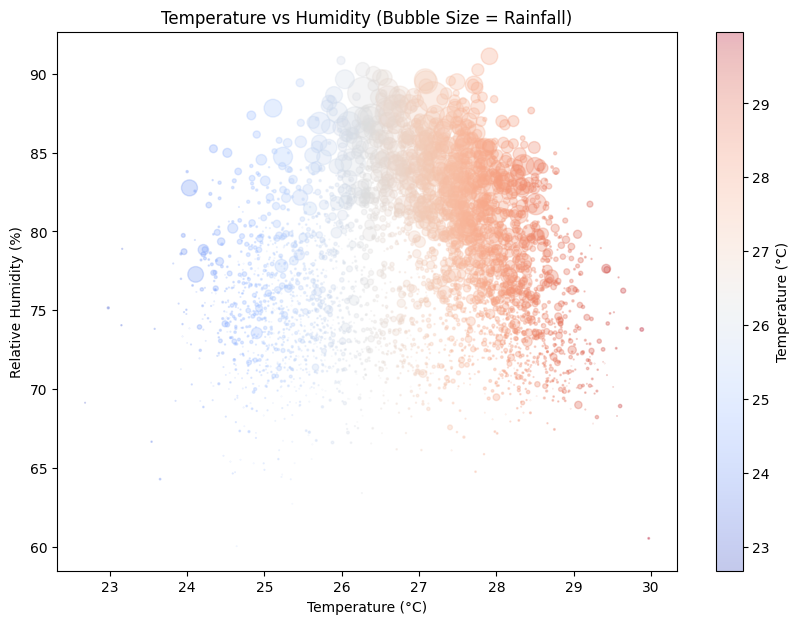

In [4]:
### distribution analysis 

# 1. Histogram of Precipitation (using log scale as suggested for skewed data) 
plt.figure(figsize=(10, 6))
import seaborn as sns # Standard alias
sns.histplot(df['PRECTOTCORR'], bins=50, kde=True, color='teal', log_scale=(False, True))
plt.title("Distribution of Daily Rainfall (Log-Scaled Frequency)", fontsize=12)
plt.xlabel("Precipitation (mm/day)")
plt.ylabel("Frequency (Log)")
plt.show()

# 2. Bubble Chart: T2M vs. RH2M (Relative Humidity) [cite: 137]
# Size of the bubble represents the amount of rainfall (PRECTOTCORR)
plt.figure(figsize=(10, 7))
plt.scatter(df['T2M'], df['RH2M'], s=df['PRECTOTCORR']*5, alpha=0.3, c=df['T2M'], cmap='coolwarm')
plt.colorbar(label='Temperature (°C)')
plt.title("Temperature vs Humidity (Bubble Size = Rainfall)", fontsize=12)
plt.xlabel("Temperature (°C)")
plt.ylabel("Relative Humidity (%)")
plt.show()

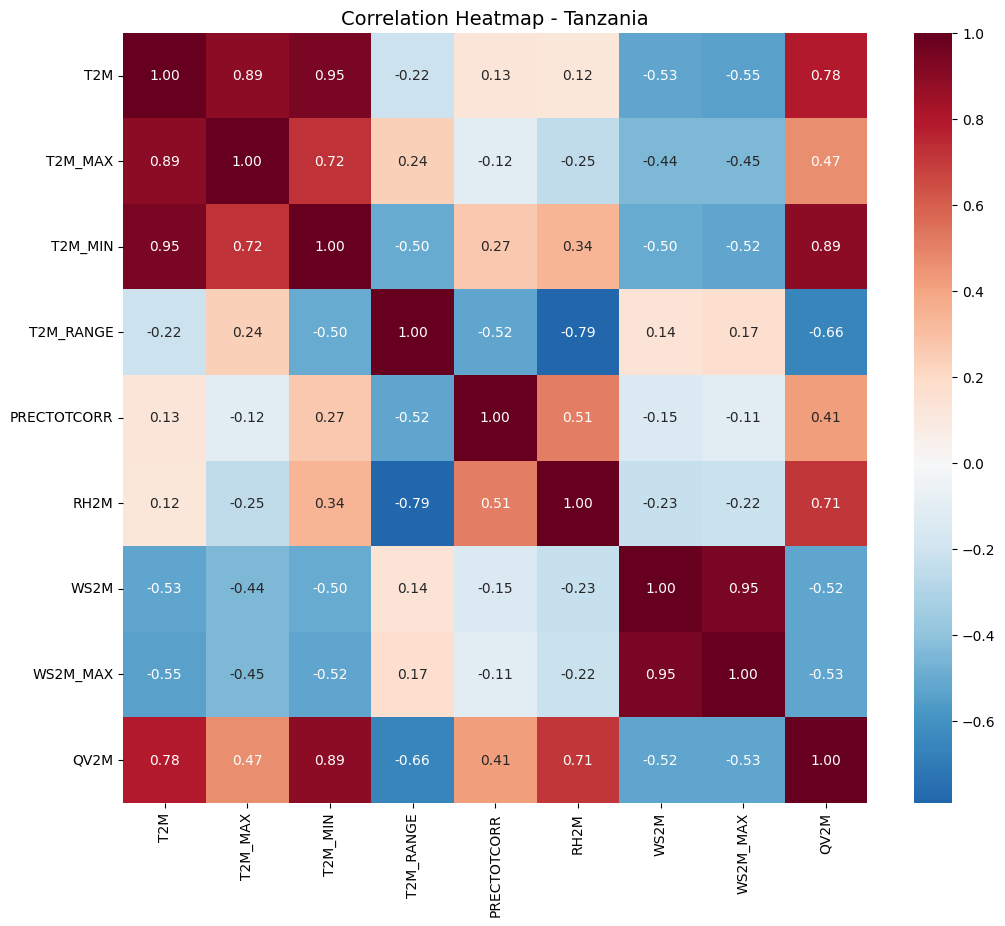

In [14]:
###Correlation analysis

# Create a correlation heatmap [cite: 132]
plt.figure(figsize=(12, 10))
# Select only numeric columns for correlation
cols = ['T2M', 'T2M_MAX', 'T2M_MIN'
, 'T2M_RANGE', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX', 'QV2M']
correlation_matrix = df[cols].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title(f"Correlation Heatmap - {df['Country'].iloc[0]}", fontsize=14)
plt.show()

In [7]:
# Create the clean filename based on the country
country_name = "tanzania" # Update this for each notebook
output_path = f"../data/cleaned_data/tanzania_clean.csv"

# Export to the data folder
df.to_csv(output_path, index=False)
print(f"Successfully saved)")



Successfully saved)
